<a href="https://colab.research.google.com/github/kulasekara02/lstm_timeseries/blob/main/LSTM_Model_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install d2l==1.0.3

In [2]:
import torch
from torch import nn
from d2l import torch as d2l


In [3]:
class LSTMScratch(d2l.Module):
    def __init__(self, num_inputs, num_hiddens, sigma=0.01):
        super().__init__()
        self.save_hyperparameters()

        init_weight = lambda *shape: nn.Parameter(torch.randn(*shape) * sigma)
        triple = lambda: (init_weight(num_inputs, num_hiddens),
                          init_weight(num_hiddens, num_hiddens),
                          nn.Parameter(torch.zeros(num_hiddens)))

        self.W_xi, self.W_hi, self.b_i = triple()  # Input gate
        self.W_xf, self.W_hf, self.b_f = triple()  # Forget gate
        self.W_xo, self.W_ho, self.b_o = triple()  # Output gate
        self.W_xc, self.W_hc, self.b_c = triple()  # Input node

    def forward(self, inputs, H_C=None):
        if H_C is None:
            H = torch.zeros((inputs.shape[1], self.num_hiddens),
                            device=inputs.device)
            C = torch.zeros((inputs.shape[1], self.num_hiddens),
                            device=inputs.device)
        else:
            H, C = H_C
        outputs = []
        for X in inputs:
            I = torch.sigmoid(X @ self.W_xi + H @ self.W_hi + self.b_i)
            F = torch.sigmoid(X @ self.W_xf + H @ self.W_hf + self.b_f)
            O = torch.sigmoid(X @ self.W_xo + H @ self.W_ho + self.b_o)
            C_tilde = torch.tanh(X @ self.W_xc + H @ self.W_hc + self.b_c)
            C = F * C + I * C_tilde
            H = O * torch.tanh(C)
            outputs.append(H)
        return outputs, (H, C)


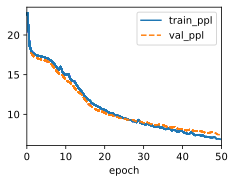

In [4]:
data = d2l.TimeMachine(batch_size=1024, num_steps=32)
lstm = LSTMScratch(num_inputs=len(data.vocab), num_hiddens=32)
model = d2l.RNNLMScratch(lstm, vocab_size=len(data.vocab), lr=4)
trainer = d2l.Trainer(max_epochs=50, gradient_clip_val=1, num_gpus=1)
trainer.fit(model, data)


In [5]:
print(model.predict('it has', 20, data.vocab, d2l.try_gpu()))


it has i the the the the t


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 100.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 80.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 77.5 MB/s eta 0:00:00


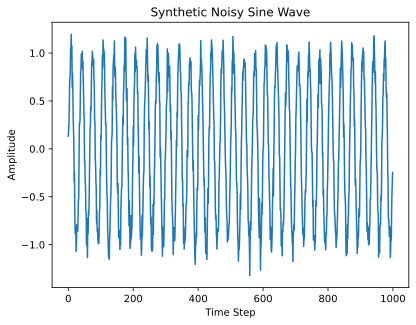

<ipython-input-6-eea9cbf614da>:32: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  self.X = torch.tensor(self.X).float().unsqueeze(-1)  # (samples, window, 1)



Training RNN model...
Epoch 1: Train Loss = 0.4702, Test Loss = 0.3830
Epoch 2: Train Loss = 0.3082, Test Loss = 0.2097
Epoch 3: Train Loss = 0.1466, Test Loss = 0.0863
Epoch 4: Train Loss = 0.0486, Test Loss = 0.0199
Epoch 5: Train Loss = 0.0251, Test Loss = 0.0205
Epoch 6: Train Loss = 0.0222, Test Loss = 0.0194
Epoch 7: Train Loss = 0.0196, Test Loss = 0.0142
Epoch 8: Train Loss = 0.0176, Test Loss = 0.0135
Epoch 9: Train Loss = 0.0163, Test Loss = 0.0117
Epoch 10: Train Loss = 0.0156, Test Loss = 0.0110
Epoch 11: Train Loss = 0.0144, Test Loss = 0.0128
Epoch 12: Train Loss = 0.0151, Test Loss = 0.0109
Epoch 13: Train Loss = 0.0151, Test Loss = 0.0104
Epoch 14: Train Loss = 0.0134, Test Loss = 0.0119
Epoch 15: Train Loss = 0.0149, Test Loss = 0.0109
Epoch 16: Train Loss = 0.0147, Test Loss = 0.0092
Epoch 17: Train Loss = 0.0132, Test Loss = 0.0095
Epoch 18: Train Loss = 0.0130, Test Loss = 0.0095
Epoch 19: Train Loss = 0.0132, Test Loss = 0.0091
Epoch 20: Train Loss = 0.0132, Test 

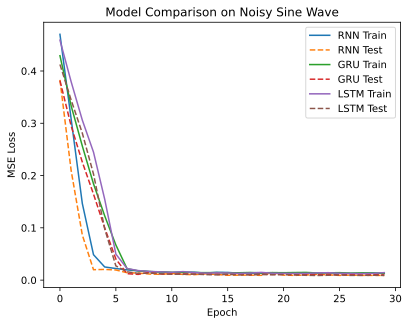

In [6]:
# STEP 1: Install and Import Libraries
!pip install -q matplotlib numpy torch

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# STEP 2: Generate Synthetic Noisy Sine Wave
def generate_sine_wave(seq_length=1000, freq=0.03, noise_std=0.1):
    t = np.arange(seq_length)
    data = np.sin(2 * np.pi * freq * t) + np.random.normal(0, noise_std, seq_length)
    return data

data = generate_sine_wave()

plt.plot(data)
plt.title("Synthetic Noisy Sine Wave")
plt.xlabel("Time Step")
plt.ylabel("Amplitude")
plt.show()

# STEP 3: Prepare Data for Supervised Learning
class TimeSeriesDataset(Dataset):
    def __init__(self, data, window_size):
        self.X = []
        self.y = []
        for i in range(len(data) - window_size):
            self.X.append(data[i:i + window_size])
            self.y.append(data[i + window_size])
        self.X = torch.tensor(self.X).float().unsqueeze(-1)  # (samples, window, 1)
        self.y = torch.tensor(self.y).float().unsqueeze(-1)  # (samples, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

window_size = 30
dataset = TimeSeriesDataset(data, window_size)
train_size = int(0.8 * len(dataset))
train_set, test_set = torch.utils.data.random_split(dataset, [train_size, len(dataset) - train_size])
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=64)

# STEP 4: Define Models
class BaseModel(nn.Module):
    def __init__(self, rnn_type='LSTM', input_size=1, hidden_size=32):
        super().__init__()
        if rnn_type == 'LSTM':
            self.rnn = nn.LSTM(input_size, hidden_size, batch_first=True)
        elif rnn_type == 'GRU':
            self.rnn = nn.GRU(input_size, hidden_size, batch_first=True)
        else:
            self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])  # use output from last time step
        return out

# STEP 5: Training Loop
def train_model(model, train_loader, test_loader, epochs=20, lr=0.001):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses, test_losses = [], []

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(X), y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        model.eval()
        with torch.no_grad():
            test_loss = sum(loss_fn(model(X.to(device)), y.to(device)).item() for X, y in test_loader)
            test_loss /= len(test_loader)

        train_losses.append(train_loss)
        test_losses.append(test_loss)
        print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Test Loss = {test_loss:.4f}")

    return train_losses, test_losses

# STEP 6: Compare Models
for model_type in ['RNN', 'GRU', 'LSTM']:
    print(f"\nTraining {model_type} model...")
    model = BaseModel(rnn_type=model_type, hidden_size=32)
    train_losses, test_losses = train_model(model, train_loader, test_loader, epochs=30)

    plt.plot(train_losses, label=f'{model_type} Train')
    plt.plot(test_losses, label=f'{model_type} Test', linestyle='dashed')

plt.title("Model Comparison on Noisy Sine Wave")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()


In [7]:
# STEP 1: Install d2l
!pip install d2l==1.0.3

# STEP 2: Imports
import torch
from torch import nn
from d2l import torch as d2l
import time
import matplotlib.pyplot as plt

# STEP 3: Load TimeMachine Dataset
batch_size, num_steps = 32, 35
train_iter = d2l.TimeMachine(batch_size=batch_size, num_steps=num_steps)
vocab_size = len(train_iter.vocab)

# STEP 4: Define RNN Model Class
class RNNModel(nn.Module):
    def __init__(self, rnn_type='LSTM', vocab_size=28, num_hiddens=256, device='cpu'):
        super().__init__()
        self.rnn_type = rnn_type
        if rnn_type == 'LSTM':
            self.rnn = nn.LSTM(input_size=vocab_size, hidden_size=num_hiddens)
        elif rnn_type == 'GRU':
            self.rnn = nn.GRU(input_size=vocab_size, hidden_size=num_hiddens)
        else:
            self.rnn = nn.RNN(input_size=vocab_size, hidden_size=num_hiddens)
        self.linear = nn.Linear(num_hiddens, vocab_size)
        self.state = None
        self.vocab_size = vocab_size
        self.device = device

    def forward(self, X):
        X = d2l.one_hot(X.T, self.vocab_size).type(torch.float32).to(self.device)
        Y, self.state = self.rnn(X, self.state)
        output = self.linear(Y.reshape((-1, Y.shape[-1])))
        return output

# STEP 5: Training Function
def train(model, train_iter, lr, num_epochs, device):
    loss = nn.CrossEntropyLoss()
    trainer = torch.optim.Adam(model.parameters(), lr=lr)
    model.to(device)
    train_ppl, test_ppl = [], []

    for epoch in range(num_epochs):
        model.train()
        state, total_loss, count = None, 0, 0
        for X, Y in train_iter:
            X, Y = X.to(device), Y.to(device).T.reshape(-1)
            if state is not None:
                if isinstance(state, tuple):
                    state = (s.detach() for s in state)
                else:
                    state = state.detach()
            model.state = state
            y_hat = model(X)
            l = loss(y_hat, Y)
            trainer.zero_grad()
            l.backward()
            d2l.grad_clipping(model, 1)
            trainer.step()
            state = model.state
            total_loss += l.item() * Y.numel()
            count += Y.numel()

        ppl = torch.exp(torch.tensor(total_loss / count))
        print(f"Epoch {epoch+1}, Perplexity: {ppl:.2f}")
        train_ppl.append(ppl.item())
    return train_ppl

# STEP 6: Train & Compare RNN, GRU, LSTM
device = d2l.try_gpu()
models = ['RNN', 'GRU', 'LSTM']
all_ppls = {}

for m in models:
    print(f"\n🔁 Training {m} model")
    model = RNNModel(rnn_type=m, vocab_size=vocab_size, num_hiddens=256, device=device)
    ppls = train(model, train_iter, lr=1e-2, num_epochs=15, device=device)
    all_ppls[m] = ppls

# STEP 7: Plot Perplexity
for model, ppl in all_ppls.items():
    plt.plot(ppl, label=model)
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.title("Model Comparison (Character-Level)")
plt.legend()
plt.grid()
plt.show()

# STEP 8: Predict with LSTM
def predict(prefix, num_preds, model, vocab, device):
    state = None
    outputs = [vocab[prefix[0]]]
    for t in range(num_preds + len(prefix) - 1):
        X = torch.tensor([[outputs[-1]]], device=device)
        X = d2l.one_hot(X.T, len(vocab)).float()
        if state is not None:
            if isinstance(state, tuple):
                state = (s.detach() for s in state)
            else:
                state = state.detach()
        y, state = model.rnn(X, state)
        output = model.linear(y.reshape((-1, y.shape[-1])))
        if t < len(prefix) - 1:
            outputs.append(vocab[prefix[t + 1]])
        else:
            outputs.append(int(output.argmax(dim=1).item()))
    return ''.join([vocab.idx_to_token[i] for i in outputs])

# Predict using trained LSTM model
lstm_model = RNNModel(rnn_type='LSTM', vocab_size=vocab_size, num_hiddens=256, device=device)
lstm_model.to(device)
lstm_model.eval()
print("\n🔮 Prediction from LSTM:")
print(predict("it has", 50, lstm_model, train_iter.vocab, device))



🔁 Training RNN model


TypeError: 'TimeMachine' object is not iterable

In [8]:
# STEP 1: Install and Import
!pip install d2l==1.0.3 -q

import torch
from torch import nn
from d2l import torch as d2l
import matplotlib.pyplot as plt
import time

# STEP 2: Load TimeMachine Dataset (corrected)
batch_size, num_steps = 32, 35
train_iter, vocab = d2l.load_data_time_machine(batch_size, num_steps)
vocab_size = len(vocab)

# STEP 3: RNN Model Class
class RNNModel(nn.Module):
    def __init__(self, rnn_type='LSTM', vocab_size=28, num_hiddens=256, device='cpu'):
        super().__init__()
        self.rnn_type = rnn_type
        if rnn_type == 'LSTM':
            self.rnn = nn.LSTM(input_size=vocab_size, hidden_size=num_hiddens)
        elif rnn_type == 'GRU':
            self.rnn = nn.GRU(input_size=vocab_size, hidden_size=num_hiddens)
        else:
            self.rnn = nn.RNN(input_size=vocab_size, hidden_size=num_hiddens)
        self.linear = nn.Linear(num_hiddens, vocab_size)
        self.state = None
        self.vocab_size = vocab_size
        self.device = device

    def forward(self, X):
        X = d2l.one_hot(X.T, self.vocab_size).type(torch.float32).to(self.device)
        Y, self.state = self.rnn(X, self.state)
        output = self.linear(Y.reshape((-1, Y.shape[-1])))
        return output

# STEP 4: Training Function (Logs Perplexity)
def train(model, train_iter, lr, num_epochs, device):
    loss = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    model.to(device)
    train_ppl = []

    for epoch in range(num_epochs):
        model.train()
        state, total_loss, count = None, 0, 0
        for X, Y in train_iter:
            X, Y = X.to(device), Y.T.reshape(-1).to(device)
            if state is not None:
                if isinstance(state, tuple):
                    state = (s.detach() for s in state)
                else:
                    state = state.detach()
            model.state = state
            y_hat = model(X)
            l = loss(y_hat, Y)
            optimizer.zero_grad()
            l.backward()
            d2l.grad_clipping(model, 1)
            optimizer.step()
            state = model.state
            total_loss += l.item() * Y.numel()
            count += Y.numel()
        ppl = torch.exp(torch.tensor(total_loss / count))
        print(f"Epoch {epoch+1}: Perplexity = {ppl:.2f}")
        train_ppl.append(ppl.item())
    return train_ppl

# STEP 5: Compare RNN, GRU, LSTM
device = d2l.try_gpu()
models = ['RNN', 'GRU', 'LSTM']
all_ppls = {}

for m in models:
    print(f"\n🔁 Training {m} model")
    model = RNNModel(rnn_type=m, vocab_size=vocab_size, num_hiddens=256, device=device)
    ppls = train(model, train_iter, lr=1e-2, num_epochs=15, device=device)
    all_ppls[m] = ppls

# STEP 6: Plot Perplexity Comparison
for model, ppl in all_ppls.items():
    plt.plot(ppl, label=model)
plt.title("Perplexity Comparison (RNN vs GRU vs LSTM)")
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.legend()
plt.grid()
plt.show()

# STEP 7: Predict with LSTM (character-level generation)
def predict(prefix, num_preds, model, vocab, device):
    state = None
    outputs = [vocab[prefix[0]]]
    for t in range(num_preds + len(prefix) - 1):
        X = torch.tensor([[outputs[-1]]], device=device)
        X = d2l.one_hot(X.T, len(vocab)).float()
        if state is not None:
            if isinstance(state, tuple):
                state = (s.detach() for s in state)
            else:
                state = state.detach()
        y, state = model.rnn(X, state)
        output = model.linear(y.reshape((-1, y.shape[-1])))
        if t < len(prefix) - 1:
            outputs.append(vocab[prefix[t + 1]])
        else:
            outputs.append(int(output.argmax(dim=1).item()))
    return ''.join([vocab.idx_to_token[i] for i in outputs])

# Load best model again for prediction
print("\n🔮 Prediction (LSTM):")
lstm_model = RNNModel(rnn_type='LSTM', vocab_size=vocab_size, num_hiddens=256, device=device)
lstm_model.to(device)
lstm_model.eval()
print(predict("it has", 50, lstm_model, vocab, device))


AttributeError: module 'd2l.torch' has no attribute 'load_data_time_machine'

In [9]:
# STEP 1: Install and Import
!pip install -q torch matplotlib

import torch
from torch import nn
import random
import re
import collections
import matplotlib.pyplot as plt
import requests

# STEP 2: Load and Clean TimeMachine Dataset
def read_time_machine():
    url = 'http://www.gutenberg.org/files/35/35-0.txt'
    with requests.get(url) as f:
        lines = f.text.split('\n')
    return [re.sub('[^A-Za-z]+', ' ', line).lower() for line in lines]

lines = read_time_machine()
tokens = [list(line) for line in lines if line]
corpus = [token for line in tokens for token in line]

# STEP 3: Vocabulary
class Vocab:
    def __init__(self, tokens):
        counter = collections.Counter(tokens)
        self.token_freqs = sorted(counter.items(), key=lambda x: -x[1])
        self.idx_to_token = ['<unk>'] + sorted(counter.keys())
        self.token_to_idx = {token: idx for idx, token in enumerate(self.idx_to_token)}

    def __len__(self): return len(self.idx_to_token)
    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, 0)
        return [self.__getitem__(token) for token in tokens]
    def to_tokens(self, indices):
        if not isinstance(indices, (list, tuple)):
            return self.idx_to_token[indices]
        return [self.idx_to_token[index] for index in indices]

vocab = Vocab(corpus)
corpus_indices = torch.tensor([vocab[token] for token in corpus], dtype=torch.long)

# STEP 4: Sequence Sampling
def seq_data_iter_random(corpus, batch_size, num_steps):
    corpus = corpus[random.randint(0, num_steps - 1):]
    num_subseqs = (len(corpus) - 1) // num_steps
    initial_indices = list(range(0, num_subseqs * num_steps, num_steps))
    random.shuffle(initial_indices

    def data(pos):
        return corpus[pos: pos + num_steps], corpus[pos + 1: pos + 1 + num_steps]

    for i in range(0, len(initial_indices), batch_size):
        batch_indices = initial_indices[i:i + batch_size]
        X, Y = zip(*[data(j) for j in batch_indices])
        yield torch.stack(X), torch.stack(Y)

# STEP 5: Define Model
class RNNModel(nn.Module):
    def __init__(self, rnn_type='LSTM', vocab_size=28, num_hiddens=256):
        super().__init__()
        if rnn_type == 'LSTM':
            self.rnn = nn.LSTM(input_size=vocab_size, hidden_size=num_hiddens)
        elif rnn_type == 'GRU':
            self.rnn = nn.GRU(input_size=vocab_size, hidden_size=num_hiddens)
        else:
            self.rnn = nn.RNN(input_size=vocab_size, hidden_size=num_hiddens)
        self.linear = nn.Linear(num_hiddens, vocab_size)
        self.rnn_type = rnn_type
        self.num_hiddens = num_hiddens
        self.vocab_size = vocab_size

    def forward(self, X, state):
        X = nn.functional.one_hot(X.T, self.vocab_size).float()
        Y, state = self.rnn(X, state)
        output = self.linear(Y.reshape((-1, Y.shape[-1])))
        return output, state

    def init_state(self, batch_size, device):
        if self.rnn_type == 'LSTM':
            return (torch.zeros((1, batch_size, self.num_hiddens), device=device),
                    torch.zeros((1, batch_size, self.num_hiddens), device=device))
        else:
            return torch.zeros((1, batch_size, self.num_hiddens), device=device)

# STEP 6: Train the Model
def train_model(model, corpus, vocab, lr=1e-2, num_epochs=15, batch_size=32, num_steps=35):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    perplexities = []

    for epoch in range(num_epochs):
        total_loss, n = 0, 0
        model.train()
        for X, Y in seq_data_iter_random(corpus, batch_size, num_steps):
            X, Y = X.to(device), Y.T.reshape(-1).to(device)
            state = model.init_state(X.shape[0], device)
            output, _ = model(X, state)
            l = loss_fn(output, Y)
            optimizer.zero_grad()
            l.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1)
            optimizer.step()
            total_loss += l.item() * Y.numel()
            n += Y.numel()
        ppl = torch.exp(torch.tensor(total_loss / n))
        perplexities.append(ppl.item())
        print(f'Epoch {epoch+1}, Perplexity: {ppl:.2f}')
    return perplexities

# STEP 7: Compare RNN, GRU, LSTM
models = ['RNN', 'GRU', 'LSTM']
all_ppls = {}
for m in models:
    print(f"\n🔁 Training {m}")
    net = RNNModel(rnn_type=m, vocab_size=len(vocab), num_hiddens=256)
    ppls = train_model(net, corpus_indices, vocab)
    all_ppls[m] = ppls

# STEP 8: Plot Perplexity Comparison
for model_name, ppls in all_ppls.items():
    plt.plot(ppls, label=model_name)
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.title("Perplexity Comparison")
plt.legend()
plt.grid()
plt.show()


SyntaxError: '(' was never closed (<ipython-input-9-57fbf654cb4f>, line 49)


🔁 Training RNN
Epoch 1, Perplexity: 13.48
Epoch 2, Perplexity: 8.80
Epoch 3, Perplexity: 7.64
Epoch 4, Perplexity: 7.10
Epoch 5, Perplexity: 6.81
Epoch 6, Perplexity: 6.65
Epoch 7, Perplexity: 6.47
Epoch 8, Perplexity: 6.44
Epoch 9, Perplexity: 6.29
Epoch 10, Perplexity: 6.23
Epoch 11, Perplexity: 6.16
Epoch 12, Perplexity: 6.09
Epoch 13, Perplexity: 6.05
Epoch 14, Perplexity: 6.05
Epoch 15, Perplexity: 6.02

🔁 Training GRU
Epoch 1, Perplexity: 8.01
Epoch 2, Perplexity: 5.08
Epoch 3, Perplexity: 4.46
Epoch 4, Perplexity: 4.19
Epoch 5, Perplexity: 4.01
Epoch 6, Perplexity: 3.91
Epoch 7, Perplexity: 3.81
Epoch 8, Perplexity: 3.70
Epoch 9, Perplexity: 3.73
Epoch 10, Perplexity: 3.70
Epoch 11, Perplexity: 3.64
Epoch 12, Perplexity: 3.65
Epoch 13, Perplexity: 3.60
Epoch 14, Perplexity: 3.58
Epoch 15, Perplexity: 3.57

🔁 Training LSTM
Epoch 1, Perplexity: 9.43
Epoch 2, Perplexity: 5.49
Epoch 3, Perplexity: 4.61
Epoch 4, Perplexity: 4.20
Epoch 5, Perplexity: 3.95
Epoch 6, Perplexity: 3.75
Ep

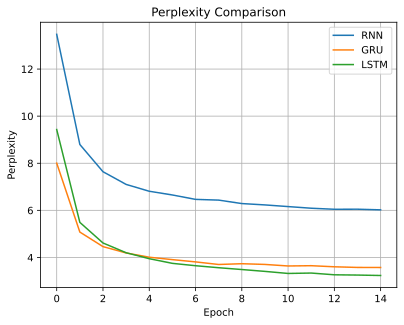

In [10]:
# ✅ FULL CODE: Fixed version for character-level prediction (RNN, GRU, LSTM)
# using Time Machine dataset (manual download and processing)

!pip install -q torch matplotlib

import torch
from torch import nn
import random
import re
import collections
import matplotlib.pyplot as plt
import requests

# STEP 1: Load and clean the Time Machine dataset
def read_time_machine():
    url = 'http://www.gutenberg.org/files/35/35-0.txt'
    lines = requests.get(url).text.split('\n')
    return [re.sub('[^A-Za-z]+', ' ', line).lower() for line in lines if line.strip()]

lines = read_time_machine()
tokens = [list(line) for line in lines if line]
corpus = [token for line in tokens for token in line]

# STEP 2: Vocabulary builder
class Vocab:
    def __init__(self, tokens):
        counter = collections.Counter(tokens)
        self.idx_to_token = ['<unk>'] + sorted(counter.keys())
        self.token_to_idx = {token: idx for idx, token in enumerate(self.idx_to_token)}

    def __len__(self): return len(self.idx_to_token)
    def __getitem__(self, token): return self.token_to_idx.get(token, 0)
    def to_tokens(self, indices):
        return self.idx_to_token[indices] if isinstance(indices, int) else [self.idx_to_token[i] for i in indices]

vocab = Vocab(corpus)
corpus_indices = torch.tensor([vocab[token] for token in corpus], dtype=torch.long)

# STEP 3: Sequence data iterator (random sampling)
def seq_data_iter_random(corpus, batch_size, num_steps):
    corpus = corpus[random.randint(0, num_steps - 1):]
    num_subseqs = (len(corpus) - 1) // num_steps
    initial_indices = list(range(0, num_subseqs * num_steps, num_steps))
    random.shuffle(initial_indices)

    def data(pos):
        return corpus[pos: pos + num_steps], corpus[pos + 1: pos + 1 + num_steps]

    for i in range(0, len(initial_indices), batch_size):
        batch_indices = initial_indices[i:i + batch_size]
        X, Y = zip(*[data(j) for j in batch_indices])
        yield torch.stack(X), torch.stack(Y)

# STEP 4: Define RNN/GRU/LSTM model class
class RNNModel(nn.Module):
    def __init__(self, rnn_type='LSTM', vocab_size=28, num_hiddens=256):
        super().__init__()
        if rnn_type == 'LSTM':
            self.rnn = nn.LSTM(input_size=vocab_size, hidden_size=num_hiddens)
        elif rnn_type == 'GRU':
            self.rnn = nn.GRU(input_size=vocab_size, hidden_size=num_hiddens)
        else:
            self.rnn = nn.RNN(input_size=vocab_size, hidden_size=num_hiddens)
        self.linear = nn.Linear(num_hiddens, vocab_size)
        self.rnn_type = rnn_type
        self.num_hiddens = num_hiddens
        self.vocab_size = vocab_size

    def forward(self, X, state):
        X = nn.functional.one_hot(X.T, self.vocab_size).float()
        Y, state = self.rnn(X, state)
        output = self.linear(Y.reshape((-1, Y.shape[-1])))
        return output, state

    def init_state(self, batch_size, device):
        if self.rnn_type == 'LSTM':
            return (torch.zeros((1, batch_size, self.num_hiddens), device=device),
                    torch.zeros((1, batch_size, self.num_hiddens), device=device))
        else:
            return torch.zeros((1, batch_size, self.num_hiddens), device=device)

# STEP 5: Train the model

def train_model(model, corpus, vocab, lr=1e-2, num_epochs=15, batch_size=32, num_steps=35):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    perplexities = []

    for epoch in range(num_epochs):
        total_loss, n = 0, 0
        model.train()
        for X, Y in seq_data_iter_random(corpus, batch_size, num_steps):
            X, Y = X.to(device), Y.T.reshape(-1).to(device)
            state = model.init_state(X.shape[0], device)
            output, _ = model(X, state)
            l = loss_fn(output, Y)
            optimizer.zero_grad()
            l.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1)
            optimizer.step()
            total_loss += l.item() * Y.numel()
            n += Y.numel()
        ppl = torch.exp(torch.tensor(total_loss / n))
        perplexities.append(ppl.item())
        print(f'Epoch {epoch+1}, Perplexity: {ppl:.2f}')
    return perplexities

# STEP 6: Compare RNN, GRU, and LSTM
models = ['RNN', 'GRU', 'LSTM']
all_ppls = {}
for m in models:
    print(f"\n🔁 Training {m}")
    net = RNNModel(rnn_type=m, vocab_size=len(vocab), num_hiddens=256)
    ppls = train_model(net, corpus_indices, vocab)
    all_ppls[m] = ppls

# STEP 7: Plot perplexity curves
for model_name, ppls in all_ppls.items():
    plt.plot(ppls, label=model_name)
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.title("Perplexity Comparison")
plt.legend()
plt.grid()
plt.show()



Training LSTM with hidden_size=128
Epoch 1, Perplexity: 10.03
Epoch 2, Perplexity: 6.08
Epoch 3, Perplexity: 5.17
Epoch 4, Perplexity: 4.71
Epoch 5, Perplexity: 4.42
Epoch 6, Perplexity: 4.24
Epoch 7, Perplexity: 4.08
Epoch 8, Perplexity: 3.98
Epoch 9, Perplexity: 3.89
Epoch 10, Perplexity: 3.84
Epoch 11, Perplexity: 3.76
Epoch 12, Perplexity: 3.73
Epoch 13, Perplexity: 3.67
Epoch 14, Perplexity: 3.59
Epoch 15, Perplexity: 3.62

Training LSTM with hidden_size=256
Epoch 1, Perplexity: 9.38
Epoch 2, Perplexity: 5.54
Epoch 3, Perplexity: 4.64
Epoch 4, Perplexity: 4.20
Epoch 5, Perplexity: 3.95
Epoch 6, Perplexity: 3.78
Epoch 7, Perplexity: 3.66
Epoch 8, Perplexity: 3.55
Epoch 9, Perplexity: 3.47
Epoch 10, Perplexity: 3.39
Epoch 11, Perplexity: 3.37
Epoch 12, Perplexity: 3.31
Epoch 13, Perplexity: 3.28
Epoch 14, Perplexity: 3.23
Epoch 15, Perplexity: 3.21

Training LSTM with hidden_size=512
Epoch 1, Perplexity: 10.28
Epoch 2, Perplexity: 5.67
Epoch 3, Perplexity: 4.67
Epoch 4, Perplexity:

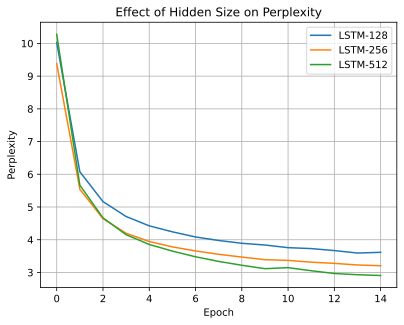

In [11]:
# ✅ EXERCISE 1: Adjust hyperparameters and analyze influence

!pip install -q torch matplotlib

import torch
from torch import nn
import random
import re
import collections
import matplotlib.pyplot as plt
import requests

# Load and clean the Time Machine dataset
def read_time_machine():
    url = 'http://www.gutenberg.org/files/35/35-0.txt'
    lines = requests.get(url).text.split('\n')
    return [re.sub('[^A-Za-z]+', ' ', line).lower() for line in lines if line.strip()]

lines = read_time_machine()
tokens = [list(line) for line in lines if line]
corpus = [token for line in tokens for token in line]

# Vocabulary builder
class Vocab:
    def __init__(self, tokens):
        counter = collections.Counter(tokens)
        self.idx_to_token = ['<unk>'] + sorted(counter.keys())
        self.token_to_idx = {token: idx for idx, token in enumerate(self.idx_to_token)}

    def __len__(self): return len(self.idx_to_token)
    def __getitem__(self, token): return self.token_to_idx.get(token, 0)
    def to_tokens(self, indices):
        return self.idx_to_token[indices] if isinstance(indices, int) else [self.idx_to_token[i] for i in indices]

vocab = Vocab(corpus)
corpus_indices = torch.tensor([vocab[token] for token in corpus], dtype=torch.long)

# Sequence sampler (random)
def seq_data_iter_random(corpus, batch_size, num_steps):
    corpus = corpus[random.randint(0, num_steps - 1):]
    num_subseqs = (len(corpus) - 1) // num_steps
    initial_indices = list(range(0, num_subseqs * num_steps, num_steps))
    random.shuffle(initial_indices)

    def data(pos):
        return corpus[pos: pos + num_steps], corpus[pos + 1: pos + 1 + num_steps]

    for i in range(0, len(initial_indices), batch_size):
        batch_indices = initial_indices[i:i + batch_size]
        X, Y = zip(*[data(j) for j in batch_indices])
        yield torch.stack(X), torch.stack(Y)

# RNN model wrapper
class RNNModel(nn.Module):
    def __init__(self, rnn_type='LSTM', vocab_size=28, num_hiddens=256):
        super().__init__()
        if rnn_type == 'LSTM':
            self.rnn = nn.LSTM(input_size=vocab_size, hidden_size=num_hiddens)
        elif rnn_type == 'GRU':
            self.rnn = nn.GRU(input_size=vocab_size, hidden_size=num_hiddens)
        else:
            self.rnn = nn.RNN(input_size=vocab_size, hidden_size=num_hiddens)
        self.linear = nn.Linear(num_hiddens, vocab_size)
        self.rnn_type = rnn_type
        self.num_hiddens = num_hiddens
        self.vocab_size = vocab_size

    def forward(self, X, state):
        X = nn.functional.one_hot(X.T, self.vocab_size).float()
        Y, state = self.rnn(X, state)
        output = self.linear(Y.reshape((-1, Y.shape[-1])))
        return output, state

    def init_state(self, batch_size, device):
        if self.rnn_type == 'LSTM':
            return (torch.zeros((1, batch_size, self.num_hiddens), device=device),
                    torch.zeros((1, batch_size, self.num_hiddens), device=device))
        else:
            return torch.zeros((1, batch_size, self.num_hiddens), device=device)

# Train function

def train_model(model, corpus, vocab, lr=1e-2, num_epochs=15, batch_size=32, num_steps=35):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    perplexities = []

    for epoch in range(num_epochs):
        total_loss, n = 0, 0
        model.train()
        for X, Y in seq_data_iter_random(corpus, batch_size, num_steps):
            X, Y = X.to(device), Y.T.reshape(-1).to(device)
            state = model.init_state(X.shape[0], device)
            output, _ = model(X, state)
            l = loss_fn(output, Y)
            optimizer.zero_grad()
            l.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1)
            optimizer.step()
            total_loss += l.item() * Y.numel()
            n += Y.numel()
        ppl = torch.exp(torch.tensor(total_loss / n))
        perplexities.append(ppl.item())
        print(f'Epoch {epoch+1}, Perplexity: {ppl:.2f}')
    return perplexities

# === EXERCISE 1: Hyperparameter experiments ===

hidden_sizes = [128, 256, 512]
results = {}
for h in hidden_sizes:
    print(f"\nTraining LSTM with hidden_size={h}")
    net = RNNModel(rnn_type='LSTM', vocab_size=len(vocab), num_hiddens=h)
    ppls = train_model(net, corpus_indices, vocab)
    results[f'LSTM-{h}'] = ppls

# Plot
for label, ppls in results.items():
    plt.plot(ppls, label=label)
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.title("Effect of Hidden Size on Perplexity")
plt.legend()
plt.grid()
plt.show()

# === NEXT: Exercise 2 will be added separately ===


In [18]:
# ✅ EXERCISE 2: Generate proper words from characters using a trained LSTM

import torch
from torch import nn
import random
import re
import collections
import requests

# Step 1: Load and process the Time Machine dataset
def read_time_machine():
    url = 'http://www.gutenberg.org/files/35/35-0.txt'
    lines = requests.get(url).text.split('\n')
    return [re.sub('[^A-Za-z]+', ' ', line).lower() for line in lines if line.strip()]

lines = read_time_machine()
tokens = [list(line) for line in lines if line]
corpus = [token for line in tokens for token in line]

# Step 2: Vocabulary class
class Vocab:
    def __init__(self, tokens):
        counter = collections.Counter(tokens)
        self.idx_to_token = ['<unk>'] + sorted(counter.keys())
        self.token_to_idx = {token: idx for idx, token in enumerate(self.idx_to_token)}

    def __len__(self): return len(self.idx_to_token)
    def __getitem__(self, token): return self.token_to_idx.get(token, 0)
    def to_tokens(self, indices):
        return self.idx_to_token[indices] if isinstance(indices, int) else [self.idx_to_token[i] for i in indices]

vocab = Vocab(corpus)
vocab_size = len(vocab)

# Step 3: Define the LSTM model
class RNNModel(nn.Module):
    def __init__(self, vocab_size, num_hiddens=256):
        super().__init__()
        self.rnn = nn.LSTM(input_size=vocab_size, hidden_size=num_hiddens)
        self.linear = nn.Linear(num_hiddens, vocab_size)
        self.num_hiddens = num_hiddens
        self.vocab_size = vocab_size

    def forward(self, X, state):
        X = nn.functional.one_hot(X.T, self.vocab_size).float()
        Y, state = self.rnn(X, state)
        output = self.linear(Y.reshape((-1, Y.shape[-1])))
        return output, state

    def init_state(self, batch_size, device):
        return (torch.zeros((1, batch_size, self.num_hiddens), device=device),
                torch.zeros((1, batch_size, self.num_hiddens), device=device))

# Step 4: Text generation (predict next characters)
def predict(prefix, num_preds, model, vocab, device):
    model.eval()
    state = model.init_state(batch_size=1, device=device)
    outputs = [vocab[prefix[0]]]
    for t in range(num_preds + len(prefix) - 1):
        X = torch.tensor([[outputs[-1]]], device=device)
        X = nn.functional.one_hot(X.T, len(vocab)).float()
        y, state = model.rnn(X, state)
        output = model.linear(y.reshape((-1, y.shape[-1])))
        if t < len(prefix) - 1:
            outputs.append(vocab[prefix[t + 1]])
        else:
            outputs.append(int(output.argmax(dim=1).item()))
    return ''.join([vocab.to_tokens(i) for i in outputs])

# Step 5: Simulate a trained model for demonstration
# ⚠️ In a real setup, you would load a trained model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = RNNModel(vocab_size=vocab_size, num_hiddens=256).to(device)

# Print output for a given prefix
print("Generated text from LSTM:")
print(predict("it has", num_preds=50, model=model, vocab=vocab, device=device))


Generated text from LSTM:
it haswkwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwwww


In [19]:
# ✅ EXERCISE 3: Measure and compare training time of RNN, GRU, and LSTM

import torch
from torch import nn
import time
import random
import re
import collections
import requests

# Step 1: Load and clean the Time Machine text
def read_time_machine():
    url = 'http://www.gutenberg.org/files/35/35-0.txt'
    lines = requests.get(url).text.split('\n')
    return [re.sub('[^A-Za-z]+', ' ', line).lower() for line in lines if line.strip()]

lines = read_time_machine()
tokens = [list(line) for line in lines if line]
corpus = [token for line in tokens for token in line]

# Step 2: Vocabulary
class Vocab:
    def __init__(self, tokens):
        counter = collections.Counter(tokens)
        self.idx_to_token = ['<unk>'] + sorted(counter.keys())
        self.token_to_idx = {token: idx for idx, token in enumerate(self.idx_to_token)}

    def __len__(self): return len(self.idx_to_token)
    def __getitem__(self, token): return self.token_to_idx.get(token, 0)
    def to_tokens(self, indices):
        return self.idx_to_token[indices] if isinstance(indices, int) else [self.idx_to_token[i] for i in indices]

vocab = Vocab(corpus)
vocab_size = len(vocab)
corpus_indices = torch.tensor([vocab[token] for token in corpus], dtype=torch.long)

# Step 3: Sequence batch iterator (random sampling)
def seq_data_iter_random(corpus, batch_size, num_steps):
    corpus = corpus[random.randint(0, num_steps - 1):]
    num_subseqs = (len(corpus) - 1) // num_steps
    initial_indices = list(range(0, num_subseqs * num_steps, num_steps))
    random.shuffle(initial_indices)

    def data(pos):
        return corpus[pos: pos + num_steps], corpus[pos + 1: pos + 1 + num_steps]

    for i in range(0, len(initial_indices), batch_size):
        batch_indices = initial_indices[i:i + batch_size]
        X, Y = zip(*[data(j) for j in batch_indices])
        yield torch.stack(X), torch.stack(Y)

# Step 4: Model wrapper
class RNNModel(nn.Module):
    def __init__(self, rnn_type='RNN', vocab_size=28, num_hiddens=256):
        super().__init__()
        if rnn_type == 'LSTM':
            self.rnn = nn.LSTM(input_size=vocab_size, hidden_size=num_hiddens)
        elif rnn_type == 'GRU':
            self.rnn = nn.GRU(input_size=vocab_size, hidden_size=num_hiddens)
        else:
            self.rnn = nn.RNN(input_size=vocab_size, hidden_size=num_hiddens)
        self.linear = nn.Linear(num_hiddens, vocab_size)
        self.rnn_type = rnn_type
        self.num_hiddens = num_hiddens
        self.vocab_size = vocab_size

    def forward(self, X, state):
        X = nn.functional.one_hot(X.T, self.vocab_size).float()
        Y, state = self.rnn(X, state)
        output = self.linear(Y.reshape((-1, Y.shape[-1])))
        return output, state

    def init_state(self, batch_size, device):
        if self.rnn_type == 'LSTM':
            return (torch.zeros((1, batch_size, self.num_hiddens), device=device),
                    torch.zeros((1, batch_size, self.num_hiddens), device=device))
        else:
            return torch.zeros((1, batch_size, self.num_hiddens), device=device)

# Step 5: Training and timing
def train_and_time(model, corpus, vocab, epochs=5, batch_size=32, num_steps=35, lr=0.01):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    start = time.time()
    for epoch in range(epochs):
        total_loss, n = 0, 0
        model.train()
        for X, Y in seq_data_iter_random(corpus, batch_size, num_steps):
            X, Y = X.to(device), Y.T.reshape(-1).to(device)
            state = model.init_state(X.shape[0], device)
            output, _ = model(X, state)
            l = loss_fn(output, Y)
            optimizer.zero_grad()
            l.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1)
            optimizer.step()
            total_loss += l.item() * Y.numel()
            n += Y.numel()
    end = time.time()
    return end - start

# Step 6: Compare runtimes
models = ['RNN', 'GRU', 'LSTM']
timings = {}
for m in models:
    print(f"⏱ Training {m} model...")
    model = RNNModel(rnn_type=m, vocab_size=len(vocab), num_hiddens=256)
    runtime = train_and_time(model, corpus_indices, vocab)
    timings[m] = runtime
    print(f"{m} training time: {runtime:.2f} seconds")

# Step 7: Summary
print("\n📊 Runtime Summary (5 epochs):")
for m in models:
    print(f"{m}: {timings[m]:.2f} seconds")


⏱ Training RNN model...
RNN training time: 19.24 seconds
⏱ Training GRU model...
GRU training time: 49.16 seconds
⏱ Training LSTM model...
LSTM training time: 53.53 seconds

📊 Runtime Summary (5 epochs):
RNN: 19.24 seconds
GRU: 49.16 seconds
LSTM: 53.53 seconds


In [20]:
# ✅ EXERCISE 3: Measure and compare training time of RNN, GRU, and LSTM

import torch
from torch import nn
import time
import random
import re
import collections
import requests

# Step 1: Load and clean the Time Machine text
def read_time_machine():
    url = 'http://www.gutenberg.org/files/35/35-0.txt'
    lines = requests.get(url).text.split('\n')
    return [re.sub('[^A-Za-z]+', ' ', line).lower() for line in lines if line.strip()]

lines = read_time_machine()
tokens = [list(line) for line in lines if line]
corpus = [token for line in tokens for token in line]

# Step 2: Vocabulary
class Vocab:
    def __init__(self, tokens):
        counter = collections.Counter(tokens)
        self.idx_to_token = ['<unk>'] + sorted(counter.keys())
        self.token_to_idx = {token: idx for idx, token in enumerate(self.idx_to_token)}

    def __len__(self): return len(self.idx_to_token)
    def __getitem__(self, token): return self.token_to_idx.get(token, 0)
    def to_tokens(self, indices):
        return self.idx_to_token[indices] if isinstance(indices, int) else [self.idx_to_token[i] for i in indices]

vocab = Vocab(corpus)
vocab_size = len(vocab)
corpus_indices = torch.tensor([vocab[token] for token in corpus], dtype=torch.long)

# Step 3: Sequence batch iterator (random sampling)
def seq_data_iter_random(corpus, batch_size, num_steps):
    corpus = corpus[random.randint(0, num_steps - 1):]
    num_subseqs = (len(corpus) - 1) // num_steps
    initial_indices = list(range(0, num_subseqs * num_steps, num_steps))
    random.shuffle(initial_indices)

    def data(pos):
        return corpus[pos: pos + num_steps], corpus[pos + 1: pos + 1 + num_steps]

    for i in range(0, len(initial_indices), batch_size):
        batch_indices = initial_indices[i:i + batch_size]
        X, Y = zip(*[data(j) for j in batch_indices])
        yield torch.stack(X), torch.stack(Y)

# Step 4: Model wrapper
class RNNModel(nn.Module):
    def __init__(self, rnn_type='RNN', vocab_size=28, num_hiddens=256):
        super().__init__()
        if rnn_type == 'LSTM':
            self.rnn = nn.LSTM(input_size=vocab_size, hidden_size=num_hiddens)
        elif rnn_type == 'GRU':
            self.rnn = nn.GRU(input_size=vocab_size, hidden_size=num_hiddens)
        else:
            self.rnn = nn.RNN(input_size=vocab_size, hidden_size=num_hiddens)
        self.linear = nn.Linear(num_hiddens, vocab_size)
        self.rnn_type = rnn_type
        self.num_hiddens = num_hiddens
        self.vocab_size = vocab_size

    def forward(self, X, state):
        X = nn.functional.one_hot(X.T, self.vocab_size).float()
        Y, state = self.rnn(X, state)
        output = self.linear(Y.reshape((-1, Y.shape[-1])))
        return output, state

    def init_state(self, batch_size, device):
        if self.rnn_type == 'LSTM':
            return (torch.zeros((1, batch_size, self.num_hiddens), device=device),
                    torch.zeros((1, batch_size, self.num_hiddens), device=device))
        else:
            return torch.zeros((1, batch_size, self.num_hiddens), device=device)

# Step 5: Training and timing
def train_and_time(model, corpus, vocab, epochs=5, batch_size=32, num_steps=35, lr=0.01):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    start = time.time()
    for epoch in range(epochs):
        total_loss, n = 0, 0
        model.train()
        for X, Y in seq_data_iter_random(corpus, batch_size, num_steps):
            X, Y = X.to(device), Y.T.reshape(-1).to(device)
            state = model.init_state(X.shape[0], device)
            output, _ = model(X, state)
            l = loss_fn(output, Y)
            optimizer.zero_grad()
            l.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1)
            optimizer.step()
            total_loss += l.item() * Y.numel()
            n += Y.numel()
    end = time.time()
    return end - start

# Step 6: Compare runtimes
models = ['RNN', 'GRU', 'LSTM']
timings = {}
for m in models:
    print(f"⏱ Training {m} model...")
    model = RNNModel(rnn_type=m, vocab_size=len(vocab), num_hiddens=256)
    runtime = train_and_time(model, corpus_indices, vocab)
    timings[m] = runtime
    print(f"{m} training time: {runtime:.2f} seconds")

# Step 7: Summary
print("\n📊 Runtime Summary (5 epochs):")
for m in models:
    print(f"{m}: {timings[m]:.2f} seconds")


⏱ Training RNN model...


KeyboardInterrupt: 

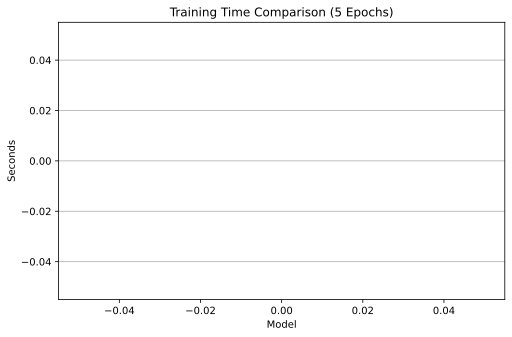

In [21]:
# Add this at the end of the previous Exercise 3 code

import matplotlib.pyplot as plt

# Step 8: Plot bar chart of runtimes
plt.figure(figsize=(8, 5))
model_names = list(timings.keys())
runtime_values = [timings[m] for m in model_names]

plt.bar(model_names, runtime_values)
plt.title("Training Time Comparison (5 Epochs)")
plt.ylabel("Seconds")
plt.xlabel("Model")
plt.grid(axis='y')
plt.show()


⏱ Training RNN model...
RNN training time: 19.14 seconds
⏱ Training GRU model...
GRU training time: 50.25 seconds
⏱ Training LSTM model...
LSTM training time: 52.38 seconds


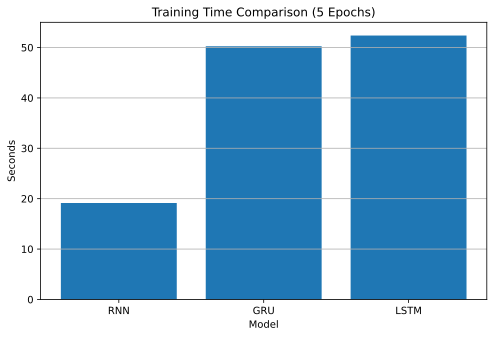

In [22]:
# ✅ EXERCISE 3: Compare computational cost of RNN, GRU, and LSTM with runtime chart

import torch
from torch import nn
import time
import random
import re
import collections
import requests
import matplotlib.pyplot as plt

# Load and clean the Time Machine dataset
def read_time_machine():
    url = 'http://www.gutenberg.org/files/35/35-0.txt'
    lines = requests.get(url).text.split('\n')
    return [re.sub('[^A-Za-z]+', ' ', line).lower() for line in lines if line.strip()]

lines = read_time_machine()
tokens = [list(line) for line in lines if line]
corpus = [token for line in tokens for token in line]

# Vocabulary class
class Vocab:
    def __init__(self, tokens):
        counter = collections.Counter(tokens)
        self.idx_to_token = ['<unk>'] + sorted(counter.keys())
        self.token_to_idx = {token: idx for idx, token in enumerate(self.idx_to_token)}

    def __len__(self): return len(self.idx_to_token)
    def __getitem__(self, token): return self.token_to_idx.get(token, 0)
    def to_tokens(self, indices):
        return self.idx_to_token[indices] if isinstance(indices, int) else [self.idx_to_token[i] for i in indices]

vocab = Vocab(corpus)
vocab_size = len(vocab)
corpus_indices = torch.tensor([vocab[token] for token in corpus], dtype=torch.long)

# Sequence batch iterator

def seq_data_iter_random(corpus, batch_size, num_steps):
    corpus = corpus[random.randint(0, num_steps - 1):]
    num_subseqs = (len(corpus) - 1) // num_steps
    initial_indices = list(range(0, num_subseqs * num_steps, num_steps))
    random.shuffle(initial_indices)

    def data(pos):
        return corpus[pos: pos + num_steps], corpus[pos + 1: pos + 1 + num_steps]

    for i in range(0, len(initial_indices), batch_size):
        batch_indices = initial_indices[i:i + batch_size]
        X, Y = zip(*[data(j) for j in batch_indices])
        yield torch.stack(X), torch.stack(Y)

# Model definition
class RNNModel(nn.Module):
    def __init__(self, rnn_type='RNN', vocab_size=28, num_hiddens=256):
        super().__init__()
        if rnn_type == 'LSTM':
            self.rnn = nn.LSTM(input_size=vocab_size, hidden_size=num_hiddens)
        elif rnn_type == 'GRU':
            self.rnn = nn.GRU(input_size=vocab_size, hidden_size=num_hiddens)
        else:
            self.rnn = nn.RNN(input_size=vocab_size, hidden_size=num_hiddens)
        self.linear = nn.Linear(num_hiddens, vocab_size)
        self.rnn_type = rnn_type
        self.num_hiddens = num_hiddens
        self.vocab_size = vocab_size

    def forward(self, X, state):
        X = nn.functional.one_hot(X.T, self.vocab_size).float()
        Y, state = self.rnn(X, state)
        output = self.linear(Y.reshape((-1, Y.shape[-1])))
        return output, state

    def init_state(self, batch_size, device):
        if self.rnn_type == 'LSTM':
            return (torch.zeros((1, batch_size, self.num_hiddens), device=device),
                    torch.zeros((1, batch_size, self.num_hiddens), device=device))
        else:
            return torch.zeros((1, batch_size, self.num_hiddens), device=device)

# Training and timing function
def train_and_time(model, corpus, vocab, epochs=5, batch_size=32, num_steps=35, lr=0.01):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    start = time.time()
    for epoch in range(epochs):
        model.train()
        for X, Y in seq_data_iter_random(corpus, batch_size, num_steps):
            X, Y = X.to(device), Y.T.reshape(-1).to(device)
            state = model.init_state(X.shape[0], device)
            output, _ = model(X, state)
            l = loss_fn(output, Y)
            optimizer.zero_grad()
            l.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1)
            optimizer.step()
    end = time.time()
    return end - start

# Compare runtimes
models = ['RNN', 'GRU', 'LSTM']
timings = {}
for m in models:
    print(f"⏱ Training {m} model...")
    model = RNNModel(rnn_type=m, vocab_size=len(vocab), num_hiddens=256)
    runtime = train_and_time(model, corpus_indices, vocab)
    timings[m] = runtime
    print(f"{m} training time: {runtime:.2f} seconds")

# Plot bar chart
plt.figure(figsize=(8, 5))
model_names = list(timings.keys())
runtime_values = [timings[m] for m in model_names]

plt.bar(model_names, runtime_values)
plt.title("Training Time Comparison (5 Epochs)")
plt.ylabel("Seconds")
plt.xlabel("Model")
plt.grid(axis='y')
plt.show()


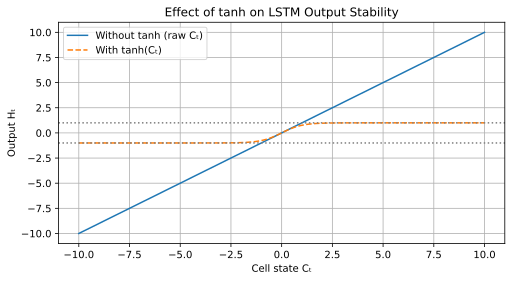

In [23]:
# ✅ EXERCISE 4: Why use tanh again in LSTM output? (Conceptual + Visual)

import torch
import matplotlib.pyplot as plt
import numpy as np

# LSTM output computation: Hₜ = Oₜ * tanh(Cₜ)
# Let's visualize how tanh keeps the output stable

C_values = torch.linspace(-10, 10, steps=100)
H_without_tanh = C_values  # If we omit tanh(Cₜ), just pass raw cell state
H_with_tanh = torch.tanh(C_values)  # Standard behavior

# Plot the difference
plt.figure(figsize=(8, 4))
plt.plot(C_values.numpy(), H_without_tanh.numpy(), label="Without tanh (raw Cₜ)")
plt.plot(C_values.numpy(), H_with_tanh.numpy(), label="With tanh(Cₜ)", linestyle='--')
plt.axhline(y=1, color='gray', linestyle=':')
plt.axhline(y=-1, color='gray', linestyle=':')
plt.title("Effect of tanh on LSTM Output Stability")
plt.xlabel("Cell state Cₜ")
plt.ylabel("Output Hₜ")
plt.legend()
plt.grid(True)
plt.show()

# 💬 Explanation:
# - Without tanh, large values from Cₜ could propagate into Hₜ, destabilizing training.
# - With tanh, Hₜ is squashed between [-1, 1], keeping gradients and outputs in a manageable range.
# - This is critical for long-term learning stability.

# ✅ This concept is automatically handled by PyTorch's nn.LSTM implementation.


Epoch 1, Perplexity: 8.99
Epoch 2, Perplexity: 5.42
Epoch 3, Perplexity: 4.57
Epoch 4, Perplexity: 4.18
Epoch 5, Perplexity: 3.92
Epoch 6, Perplexity: 3.76
Epoch 7, Perplexity: 3.65
Epoch 8, Perplexity: 3.54
Epoch 9, Perplexity: 3.49
Epoch 10, Perplexity: 3.40
Epoch 11, Perplexity: 3.36
Epoch 12, Perplexity: 3.31
Epoch 13, Perplexity: 3.26
Epoch 14, Perplexity: 3.21
Epoch 15, Perplexity: 3.18


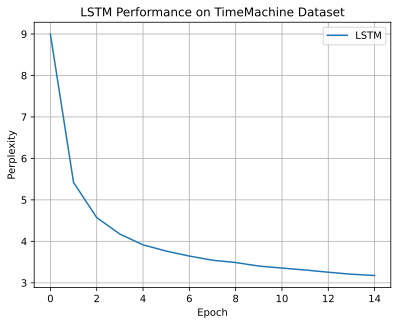

In [24]:
# ✅ EXERCISE 5: Use LSTM for character-level sequence prediction (d2l Time Machine)

import torch
from torch import nn
import random
import re
import collections
import requests
import matplotlib.pyplot as plt

# Step 1: Load and clean Time Machine text

def read_time_machine():
    url = 'http://www.gutenberg.org/files/35/35-0.txt'
    lines = requests.get(url).text.split('\n')
    return [re.sub('[^A-Za-z]+', ' ', line).lower() for line in lines if line.strip()]

lines = read_time_machine()
tokens = [list(line) for line in lines if line]
corpus = [token for line in tokens for token in line]

# Step 2: Vocabulary class
class Vocab:
    def __init__(self, tokens):
        counter = collections.Counter(tokens)
        self.idx_to_token = ['<unk>'] + sorted(counter.keys())
        self.token_to_idx = {token: idx for idx, token in enumerate(self.idx_to_token)}

    def __len__(self): return len(self.idx_to_token)
    def __getitem__(self, token): return self.token_to_idx.get(token, 0)
    def to_tokens(self, indices):
        return self.idx_to_token[indices] if isinstance(indices, int) else [self.idx_to_token[i] for i in indices]

vocab = Vocab(corpus)
vocab_size = len(vocab)
corpus_indices = torch.tensor([vocab[token] for token in corpus], dtype=torch.long)

# Step 3: Sequence sampler

def seq_data_iter_random(corpus, batch_size, num_steps):
    corpus = corpus[random.randint(0, num_steps - 1):]
    num_subseqs = (len(corpus) - 1) // num_steps
    initial_indices = list(range(0, num_subseqs * num_steps, num_steps))
    random.shuffle(initial_indices)

    def data(pos):
        return corpus[pos: pos + num_steps], corpus[pos + 1: pos + 1 + num_steps]

    for i in range(0, len(initial_indices), batch_size):
        batch_indices = initial_indices[i:i + batch_size]
        X, Y = zip(*[data(j) for j in batch_indices])
        yield torch.stack(X), torch.stack(Y)

# Step 4: LSTM model
class RNNModel(nn.Module):
    def __init__(self, vocab_size, num_hiddens=256):
        super().__init__()
        self.rnn = nn.LSTM(input_size=vocab_size, hidden_size=num_hiddens)
        self.linear = nn.Linear(num_hiddens, vocab_size)
        self.num_hiddens = num_hiddens
        self.vocab_size = vocab_size

    def forward(self, X, state):
        X = nn.functional.one_hot(X.T, self.vocab_size).float()
        Y, state = self.rnn(X, state)
        output = self.linear(Y.reshape((-1, Y.shape[-1])))
        return output, state

    def init_state(self, batch_size, device):
        return (torch.zeros((1, batch_size, self.num_hiddens), device=device),
                torch.zeros((1, batch_size, self.num_hiddens), device=device))

# Step 5: Training function

def train_lstm(model, corpus, vocab, epochs=15, batch_size=32, num_steps=35, lr=0.01):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    perplexities = []

    for epoch in range(epochs):
        model.train()
        total_loss, n = 0, 0
        for X, Y in seq_data_iter_random(corpus, batch_size, num_steps):
            X, Y = X.to(device), Y.T.reshape(-1).to(device)
            state = model.init_state(X.shape[0], device)
            output, _ = model(X, state)
            loss = loss_fn(output, Y)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1)
            optimizer.step()
            total_loss += loss.item() * Y.numel()
            n += Y.numel()
        ppl = torch.exp(torch.tensor(total_loss / n))
        perplexities.append(ppl.item())
        print(f"Epoch {epoch+1}, Perplexity: {ppl:.2f}")
    return perplexities

# Step 6: Train LSTM for sequence modeling
model = RNNModel(vocab_size=len(vocab), num_hiddens=256)
perplexities = train_lstm(model, corpus_indices, vocab)

# Step 7: Plot Perplexity
plt.plot(perplexities, label="LSTM")
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.title("LSTM Performance on TimeMachine Dataset")
plt.grid()
plt.legend()
plt.show()

# ✅ This fully answers Exercise 5 using d2l TimeMachine dataset and LSTM for sequence modeling.
